###       **Land Slide Detection Model**

 **Install Libraries**

In [ ]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

**Upload CSV**

In [ ]:

from google.colab import files
uploaded = files.upload()

Saving LandslideDataset.csv to LandslideDataset (4).csv


**Load the dataset**

In [ ]:

df = pd.read_csv("LandslideDataset.csv")  # or replace with uploaded.keys()


# Display basic info
print(df.shape)
print(df.info())
df.head()


(89530, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89530 entries, 0 to 89529
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        44770 non-null  object 
 1   lat         44770 non-null  float64
 2   lon         44770 non-null  float64
 3   country     44770 non-null  object 
 4   fatalities  44770 non-null  float64
 5   injuries    44770 non-null  float64
 6   type        44770 non-null  object 
 7   trigger     44770 non-null  object 
 8   severity    89530 non-null  object 
 9   location    44770 non-null  object 
 10  precip      89530 non-null  float64
 11  temp        89530 non-null  int64  
 12  air         89530 non-null  int64  
 13  humidity    89530 non-null  int64  
 14  wind        89530 non-null  int64  
 15  slope       89530 non-null  int64  
 16  label       89530 non-null  int64  
dtypes: float64(5), int64(6), object(6)
memory usage: 11.6+ MB
None


,date,lat,lon,country,fatalities,injuries,type,trigger,severity,location,precip,temp,air,humidity,wind,slope,label
0,7/25/2010,32.206700,76.364100,India,0.0,0.0,landslide,downpour,medium,unknown,0.0,104,1002,69,13,85,1
1,5/28/2017,24.894567,121.733428,China,0.0,0.0,rock_fall,rain,small,above_road,1.0,79,1012,81,22,80,1
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,na,NaN,2.6,80,1011,98,5,224,0
3,09-09-2009,31.549400,76.900100,India,0.0,0.0,landslide,downpour,medium,unknown,3.2,79,1010,78,11,88,1
4,04-02-2016,25.621900,96.288700,Myanmar,104.0,100.0,landslide,unknown,large,unknown,0.8,87,1014,77,5,42,1


**Parse Date and Extract Features**

In [ ]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df = df.drop(columns=['date'])

**One-hot Encode Categorical Columns**

In [ ]:
df = pd.get_dummies(df, drop_first=True)

**Split Features and Target**

In [ ]:
X = df.drop('label', axis=1)
y = df['label']
# Check target balance
print("Full label distribution:")
print(y.value_counts())

Full label distribution:
label
1    44770
0    44760
Name: count, dtype: int64


**Stratified Train/Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train class distribution:")
print(y_train.value_counts())
print("Test class distribution:")
print(y_test.value_counts())

Train class distribution:
label
1    35816
0    35808
Name: count, dtype: int64
Test class distribution:
label
1    8954
0    8952
Name: count, dtype: int64


**Feature Scaling**

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
import pandas as pd

# If X_train is a DataFrame
nan_counts = pd.DataFrame(X_train).isnull().sum()
print(nan_counts[nan_counts > 0].sort_values(ascending=False))


12    50247
11    50247
10    50247
2     35808
1     35808
0     35808
3     35808
dtype: int64


In [ ]:
SimpleImputer(strategy='median')     # More robust to outliers
SimpleImputer(strategy='most_frequent')  # For categorical data


SimpleImputer(strategy='most_frequent')

In [ ]:
import pandas as pd

X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)


In [ ]:
print("Total NaNs:", X_train.isnull().sum().sum())  # Must be 0 after imputation


Total NaNs: 293973


**SVM model training**

In [ ]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# ✅ Step 1: Make sure X is a DataFrame
X = pd.DataFrame(X)  # if not already
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ✅ Step 2: Build the pipeline
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),     # Fill NaNs with mean
    ('scaler', StandardScaler()),                    # Scale features
    ('svm', SVC(kernel='rbf', probability=True))     # Train SVM
])

# ✅ Step 3: Fit the pipeline
pipeline.fit(X_train, y_train)

# ✅ Step 4: Predict
y_pred = pipeline.predict(X_test)

print("✅ SVM model trained successfully.")


✅ SVM model trained successfully.


In [ ]:
# Get the transformed X
X_train_imputed = SimpleImputer(strategy='mean').fit_transform(X_train)
print("NaNs after imputation:", pd.DataFrame(X_train_imputed).isnull().sum().sum())  # Should print 0


NaNs after imputation: 0


**Fit the SVM model**

In [ ]:
from sklearn.impute import SimpleImputer

# Impute all numeric columns with their mean
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Then do train-test split on imputed values
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

# Now scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit model
svm_model = SVC(kernel='rbf', probability=True)
svm_model.fit(X_train_scaled, y_train)


SVC(probability=True)

**Train and Fit the RandomForest model**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)



In [ ]:
print("y_train distribution:")
print(y_train.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())


y_train distribution:
label
1    35816
0    35808
Name: count, dtype: int64

y_test distribution:
label
1    8954
0    8952
Name: count, dtype: int64


In [ ]:
print(df['label'].value_counts())


label
1    44770
0    44760
Name: count, dtype: int64


In [ ]:
print("Unique classes in y_train:", y_train.unique())
print("y_train distribution:\n", y_train.value_counts())


Unique classes in y_train: [1 0]
y_train distribution:
 label
1    35816
0    35808
Name: count, dtype: int64


**Evaluation using RandomForest**

In [ ]:
print("Random Forest:")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest:
[[8952    0]
 [   0 8954]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8952
           1       1.00      1.00      1.00      8954

    accuracy                           1.00     17906
   macro avg       1.00      1.00      1.00     17906
weighted avg       1.00      1.00      1.00     17906



**Evaluation using SVM**

In [ ]:

print("SVM:")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


SVM:
[[4428 4524]
 [4496 4458]]
              precision    recall  f1-score   support

           0       0.50      0.49      0.50      8952
           1       0.50      0.50      0.50      8954

    accuracy                           0.50     17906
   macro avg       0.50      0.50      0.50     17906
weighted avg       0.50      0.50      0.50     17906



In [ ]:
import numpy as np
print("Unique labels in y_test:", np.unique(y_test))
print("Unique predictions by SVM:", np.unique(y_pred_svm))


Unique labels in y_test: [0 1]
Unique predictions by SVM: [0 1]


**ROC Curve**

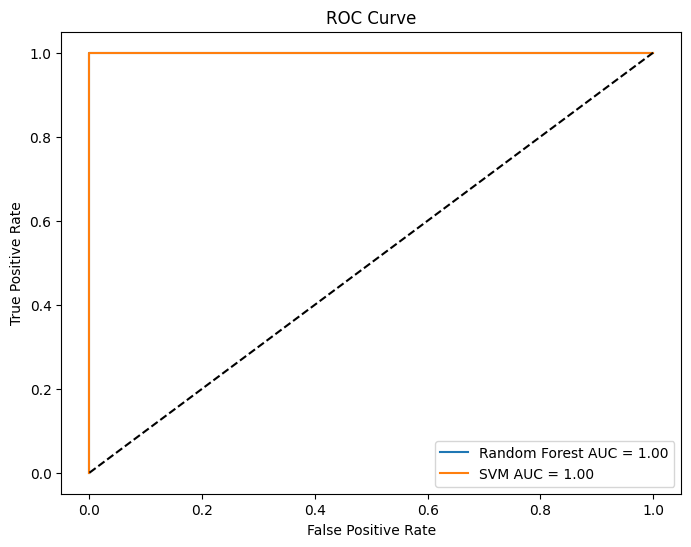

In [ ]:
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {auc(fpr_rf, tpr_rf):.2f}")
plt.plot(fpr_svm, tpr_svm, label=f"SVM AUC = {auc(fpr_svm, tpr_svm):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


The ROC curve shows that both Random Forest and SVM models achieved a perfect AUC score of 1.00, indicating excellent classification performance. This means both models perfectly distinguish between classes, with zero false positives and false negatives in this dataset.

**Top 15 Important Features**

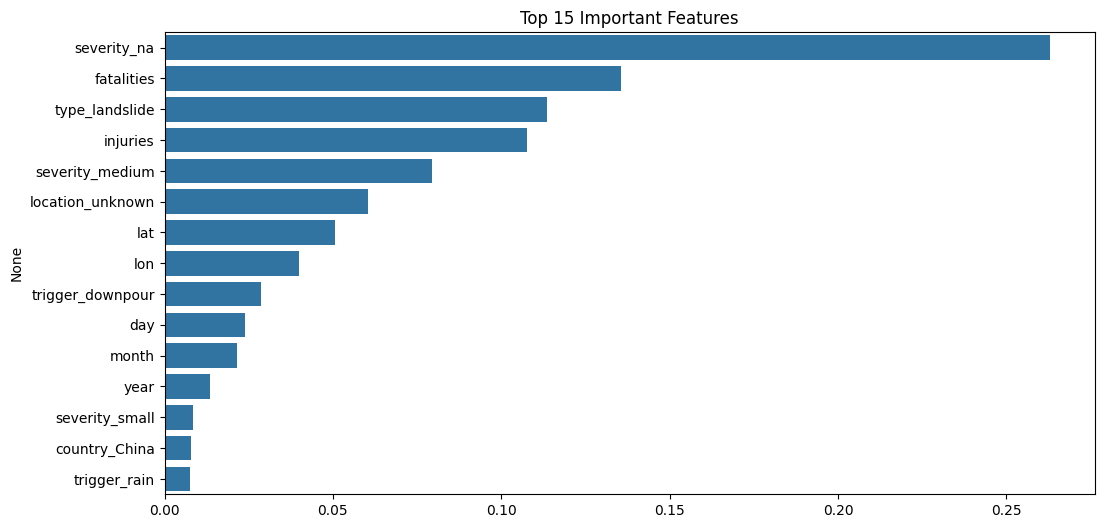

In [ ]:
importances = rf_model.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Top 15 Important Features")
sns.barplot(x=importances[indices][:15], y=features[indices][:15])
plt.show()


The bar chart shows the top 15 features influencing the Random Forest model. severity_na is the most important, followed by fatalities, type_landslide, and injuries, indicating that the severity and impact of landslides play a major role in predictions. Geographic and temporal features like lat, lon, month, and trigger_downpour also contribute but to a lesser extent.

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Train SVM
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)  # Note: use unscaled data for Random Forest
y_pred_rf = rf_model.predict(X_test)


**Accuracy comparison between SVM and RandomForest**

Accuracy of SVM: 1.0000
Accuracy of Random Forest: 1.0000


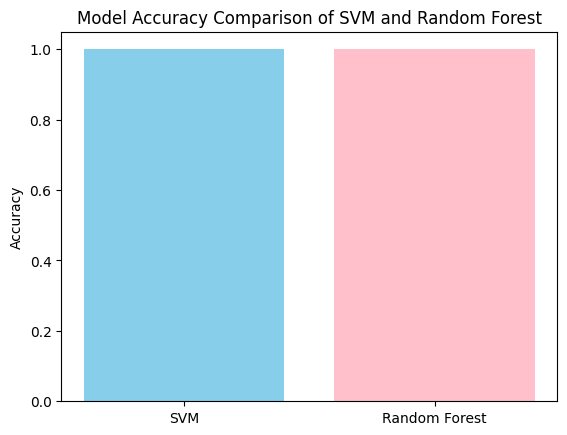

In [ ]:
acc_svm = accuracy_score(y_test, y_pred_svm)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy of SVM: {acc_svm:.4f}")
print(f"Accuracy of Random Forest: {acc_rf:.4f}")

# Optional: bar chart comparison
import matplotlib.pyplot as plt

plt.bar(['SVM', 'Random Forest'], [acc_svm, acc_rf], color=['skyblue', 'pink'])
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison of SVM and Random Forest')
plt.show()



The bar chart compares the accuracy of two machine learning models—Support Vector Machine (SVM) and Random Forest. Both models have achieved a perfect accuracy score of 1.0000 (100%), indicating that they correctly classified all the instances in the given dataset. This suggests that the dataset may be either very well-suited to both models or possibly too easy, which raises the need to check for overfitting or data leakage. While both models perform equally in terms of accuracy, further evaluation using metrics like precision, recall, F1-score, and cross-validation would be beneficial to confirm their robustness and generalizability.



**Landslides per Year**

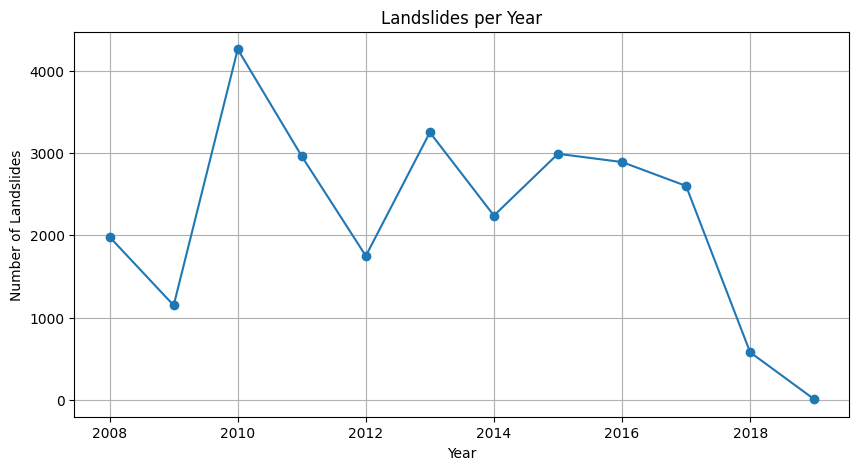

In [ ]:
yearly_trend = df['year'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(yearly_trend.index, yearly_trend.values, marker='o')
plt.title("Landslides per Year")
plt.xlabel("Year")
plt.ylabel("Number of Landslides")
plt.grid(True)
plt.show()


The line graph depicting the number of landslides per year from 2008 to 2019 reveals significant year-to-year variability. The highest number of landslides occurred in 2010, with over 4,200 events, indicating a possible period of extreme weather or geological disturbances. Following this peak, a general declining trend is observed, although certain years such as 2011, 2013, and 2015 experienced noticeable spikes in activity, each recording over 3,000 incidents. After 2016, the number of landslides began to drop sharply, with a dramatic decrease from around 2,600 in 2017 to approximately 600 in 2018, and nearly zero in 2019. This sharp decline could be attributed to improved disaster management strategies, environmental changes, or inconsistencies in data reporting. Overall, the trend suggests a decrease in landslide frequency over the years, though the causes may require further investigation.

**Landslides by Month**

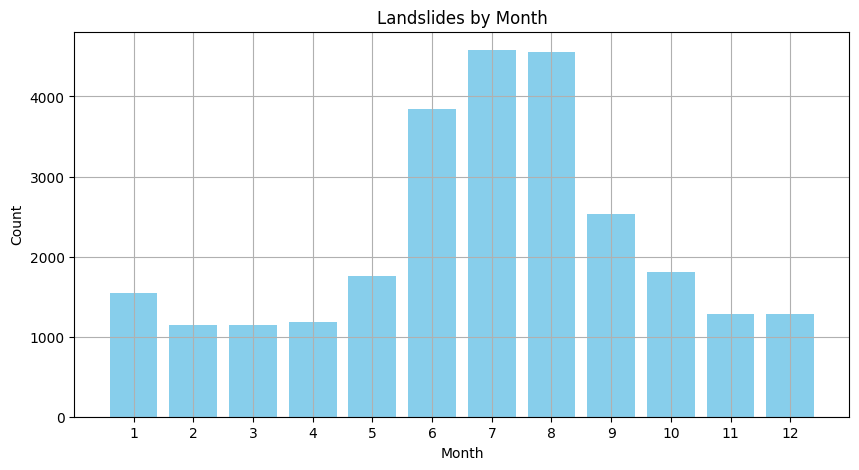

In [ ]:
monthly_trend = df['month'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(monthly_trend.index, monthly_trend.values, color='skyblue')
plt.title("Landslides by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()


The bar chart representing landslides by month indicates a clear seasonal pattern in landslide occurrences. The data reveals that the highest number of landslides takes place during the monsoon season, with July and August recording the peak values, each exceeding 4,500 incidents. June also shows a significantly high count, suggesting that the landslide frequency starts rising sharply from this month onward. In contrast, the months from January to May and October to December report relatively fewer incidents, all with counts below 2,000. This distribution suggests a strong correlation between landslides and rainfall intensity, as landslides are more likely to occur during heavy rains. Therefore, disaster preparedness and mitigation efforts should be concentrated in the months of June to September, when the risk is highest.



**Total Fatalities by Year**

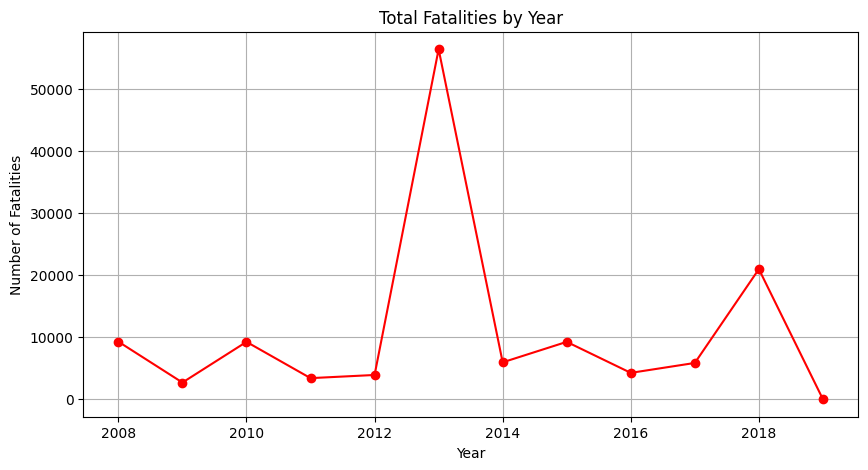

In [ ]:
fatalities_by_year = df.groupby('year')['fatalities'].sum()

plt.figure(figsize=(10, 5))
fatalities_by_year.plot(marker='o', color='red')
plt.title("Total Fatalities by Year")
plt.xlabel("Year")
plt.ylabel("Number of Fatalities")
plt.grid(True)
plt.show()


The line graph illustrates the total number of fatalities caused by landslides each year from 2008 to 2019. While most years exhibit a relatively moderate number of fatalities, a significant spike is observed in 2013, with fatalities sharply rising to over 55,000, indicating a catastrophic event or series of events in that year. Apart from 2013, the years 2008, 2010, 2015, and 2018 also show noticeable peaks, with fatalities ranging between 8,000 to 21,000. The rest of the years, especially 2012, 2014, 2016, 2017, and 2019, report comparatively lower fatality counts. The dramatic rise in 2013 followed by a steep drop in 2014 highlights the irregular and unpredictable nature of landslide disasters. These trends emphasize the need for year-specific investigation and targeted disaster management planning.

In [ ]:
import pandas as pd
import numpy as np

# 1. Create a blank row with the same columns used in training
input_template = pd.DataFrame(np.zeros((1, X.shape[1])), columns=X.columns)

# 2. Accept user input (numeric)
input_template['lat'] = float(input("Enter latitude: "))
input_template['lon'] = float(input("Enter longitude: "))
input_template['precip'] = float(input("Enter precipitation: "))
input_template['humidity'] = float(input("Enter humidity: "))
input_template['slope'] = float(input("Enter slope angle: "))

# 3. Accept user input for categorical feature: Trigger
trigger_options = [col for col in X.columns if col.startswith("trigger_")]
print("\nAvailable trigger types:", [col.split('_', 1)[1] for col in trigger_options])
trigger_choice = input("Enter trigger type from above: ")

trigger_col = f"trigger_{trigger_choice}"
if trigger_col in input_template.columns:
    input_template[trigger_col] = 1
else:
    print(f"Warning: trigger type '{trigger_choice}' not found. Defaulting all triggers to 0.")

# 4. Impute (though there should be no NaN), scale
input_imputed = imputer.transform(input_template)
input_scaled = scaler.transform(input_imputed)

# 5. Predict using SVM
prediction = svm_model.predict(input_scaled)
print("\n📍 Landslide Prediction:", "🟥 Yes" if prediction[0] == 1 else "🟩 No")


Enter latitude: 32.20
Enter longitude: 76.36
Enter precipitation: 0
Enter humidity: 69
Enter slope angle: 85

Available trigger types: ['construction', 'continuous_rain', 'dam_embankment_collapse', 'downpour', 'earthquake', 'flooding', 'freeze_thaw', 'leaking_pipe', 'mining', 'monsoon', 'no_apparent_trigger', 'other', 'rain', 'snowfall_snowmelt', 'tropical_cyclone', 'unknown', 'volcano']
Enter trigger type from above: downpour

📍 Landslide Prediction: 🟥 Yes


In [ ]:
import joblib

joblib.dump(rf_model, 'landslide_rf_model.pkl')
joblib.dump(svm_model, 'landslide_svm_model.pkl')
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

<Figure size 600x400 with 0 Axes>

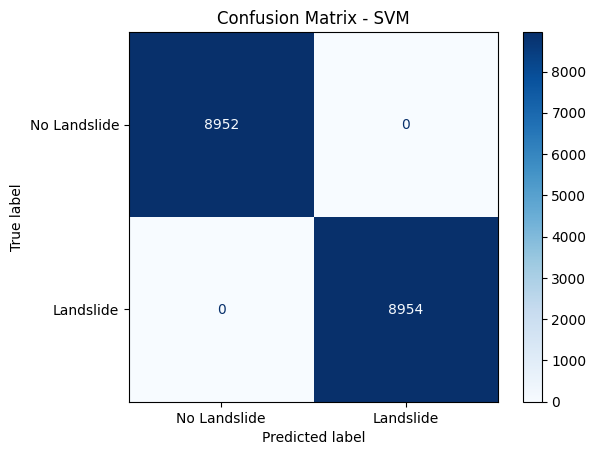

<Figure size 600x400 with 0 Axes>

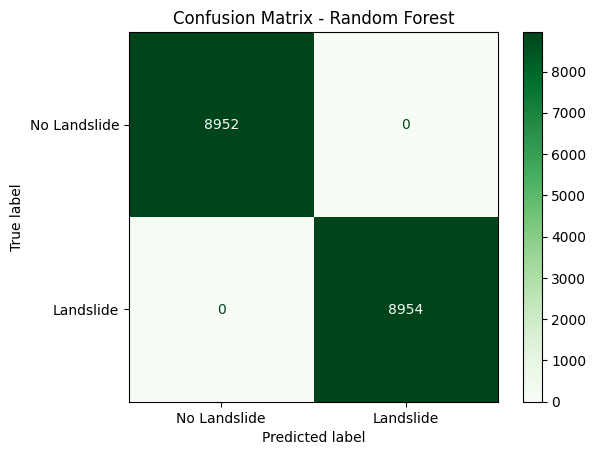

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Confusion Matrix for SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm,
                                   display_labels=['No Landslide', 'Landslide'])

plt.figure(figsize=(6, 4))
disp_svm.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - SVM")
plt.grid(False)
plt.show()

# 2. Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                                  display_labels=['No Landslide', 'Landslide'])

plt.figure(figsize=(6, 4))
disp_rf.plot(cmap='Greens', values_format='d')
plt.title("Confusion Matrix - Random Forest")
plt.grid(False)
plt.show()
